In [39]:
# Standard library
import math
import random

# Data manipulation
import numpy as np
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import (
    KFold,
    cross_validate
)
from sklearn.preprocessing import StandardScaler

# Explainability
import shap

# Custom utilities
import utils.cross_validation as cval

import numpy as np
import pandas as pd
import random
from math import radians, sin, cos, sqrt, asin


In [45]:
biome_mapping = {
        0: 'Boreal and Tundra forests',
        1: 'Flooded grasslands',
        2: 'Mangroves',
        3: 'Mediterranean woodlands',
        4: 'Temperate broadleaf forests',
        5: 'Temperate conifer forests',
        6: 'Temperate grasslands',
        7: 'Tropical',
        8: 'Tropical',
        9: 'Tropical',
        10: 'Tropical',
        11: 'Boreal and Tundra forests',
        12: 'Xeric shrublands',
        13: np.nan
    }


def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2  = r2_score(y_test, y_pred, multioutput='raw_values')

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    n_outputs = y_test.shape[1] if y_test.ndim > 1 else 1

    fig, axes = plt.subplots(1, n_outputs, figsize=(5 * n_outputs, 4), squeeze=False)

    for i in range(n_outputs):
        ax = axes[0, i]
        y_t = y_test[:, i] if n_outputs > 1 else y_test
        y_p = y_pred[:, i] if n_outputs > 1 else y_pred

        ax.hexbin(y_t, y_p, gridsize=40, cmap='YlOrRd', mincnt=1)
        fig.colorbar(ax.collections[0], ax=ax, label='Count')

        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect fit')

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Output {i+1} | MAE: {mae[i]:.3f} | R²: {r2[i]:.3f}')
        ax.legend()

    plt.tight_layout()
    plt.show()

    return mae, r2

def train_rf_cv(X, y, n_splits=5, rf_params=None):
    if rf_params is None:
        rf_params = {
            'n_estimators': 200,
            'max_depth': None,
            'min_samples_leaf': 2,
            'n_jobs': -1,
            'random_state': 42
        }

    # Fix: reset index to avoid positional/label index mismatch
    X = np.array(X)
    y = np.array(y)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = RandomForestRegressor(**rf_params)

    fold_mape, fold_r2, fold_y_val= [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]  # use .iloc
        y_train, y_val = y[train_idx], y[val_idx]  # use .iloc

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mape = mean_absolute_percentage_error(y_val, y_pred, multioutput='raw_values')
        r2  = r2_score(y_val, y_pred, multioutput='raw_values')
        y_mean = np.mean(y_val)
        fold_mape.append(mape)
        fold_r2.append(r2)
        fold_y_val.append(y_mean)
        
    fold_mape = np.array(fold_mape)
    fold_r2  = np.array(fold_r2)

    return model, fold_mape, fold_r2, fold_y_val


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c


def select_points_with_buffer(df, n_points, buffer_km=100, lat_col='lat', lon_col='lon', 
                              random_seed=None):
    """
    Randomly select n_points and remove any points within buffer_km of selected points
    
    Parameters:
    - df: DataFrame with coordinates
    - n_points: number of points to randomly select
    - buffer_km: buffer radius in kilometers (default: 100)
    - lat_col: name of latitude column
    - lon_col: name of longitude column
    - random_seed: random seed for reproducibility
    
    Returns:
    - selected: DataFrame of selected points
    - remaining: DataFrame of points outside buffer
    - removed: DataFrame of points within buffer of selected points
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
        random.seed(random_seed)
    
    # Get unique coordinates (if multiple rows per location)
    coords = df[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)
    
    if len(coords) < n_points:
        raise ValueError(f"Only {len(coords)} unique points available, but {n_points} requested")
    
    # Randomly select n_points
    selected_indices = np.random.choice(len(coords), n_points, replace=False)
    selected_coords = coords.iloc[selected_indices].copy()
    
    # Identify points within buffer
    selected_points = []
    removed_points = []
    remaining_points = []
    
    for idx, row in coords.iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        
        # Check distance to all selected points
        within_buffer = False
        for _, sel_row in selected_coords.iterrows():
            dist = haversine(lat, lon, sel_row[lat_col], sel_row[lon_col])
            if dist <= buffer_km:
                within_buffer = True
                break
        
        if idx in selected_indices:
            selected_points.append(idx)
        elif within_buffer:
            removed_points.append(idx)
        else:
            remaining_points.append(idx)
    
    # Create DataFrames
    selected_df = df.iloc[selected_points].copy()
    removed_df = df.iloc[removed_points].copy()
    remaining_df = df.iloc[remaining_points].copy()
    
    return selected_df, remaining_df, removed_df


def train_test_split(df, random_key, n_points_to_select=50, buffer_km=100):
    sub_df = df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right','DIA',
        'lon_bin', 'lat_bin', 'TPA_UNADJ', 'WSCI'])

    
    random_key =10

    selected, remaining, removed = select_points_with_buffer(
        sub_df, 
        n_points=n_points_to_select,
        buffer_km=buffer_km,
        lat_col='lat',
        lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon'])
    train= remaining.drop(columns=['lat', 'lon'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test


def data_processing_v2(df, biome_mapping):
     
    # df = df[df['biome'].isin([4,5,6,12])]

    df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    biome_dfs = {k: v for k, v in joined.groupby('biome')}
    return biome_dfs

In [4]:

fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
# sd_df = sd_df[sd_df["WSCI"] >= -1000]
# fd_df = fd_df[fd_df["WSCI"] >= -1000]


sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]

shared_pids = set(sd_df["PID"]).intersection(fd_df["PID"])

# Filter both dataframes to only shared PIDs
sd_df = sd_df[sd_df["PID"].isin(shared_pids)]
fd_df = fd_df[fd_df["PID"].isin(shared_pids)]

#Preprocessing the data for Random forest regression
fbiome_dfs= data_processing_v2(fd_df, biome_mapping)
sbiome_dfs =data_processing_v2(sd_df, biome_mapping)

In [36]:
biomes_list=['Temperate broadleaf forests','Temperate conifer forests',
            'Temperate grasslands' ]
 

results_df=pd.DataFrame(columns=['biome', 'mape', 'r2', 'Stability'])

for biome in biomes_list:
    print(f"Biome: {biome}")

    random.seed(42)
    random_keys = [random.randint(0, 500) for _ in range(10)]

    for key in random_keys:
        random_key=key
        fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=random_key, test_size=0.4)
        # sX_train, sy_train, sX_test, sy_test = train_test_split(sbiome_dfs[biome], random_key=27, test_size=0.4)
        
        fmodel, mape, r2, y_val = train_rf_cv(fX_train, fy_train, n_splits=10)

        mape = [item[0] for item in mape]
        r2 = [item[0] for item in r2]
        
        sub_df = pd.DataFrame(
            list(zip([biome]*len(mape), mape, r2, y_val)),
            columns=['biome', 'mape', 'r2', 'Stability']
        )
        results_df=pd.concat([results_df, sub_df], ignore_index=True)

Biome: Temperate broadleaf forests
Biome: Temperate conifer forests
Biome: Temperate grasslands


In [57]:
results_df['mape']=results_df['mape']/100

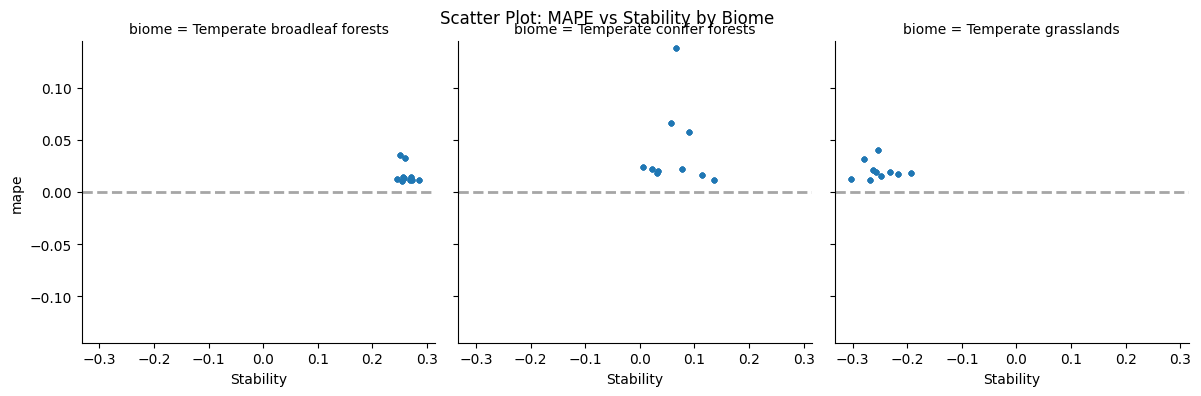

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create FacetGrid with scatter plots
g = sns.FacetGrid(results_df, col="biome", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(plt.scatter, "Stability", 'mape', alpha=0.5, s=10)

# Add MAPE=0 line centered in each subplot
for ax in g.axes.flat:
    # Get y-axis limits
    ymin, ymax = ax.get_ylim()
    
    # Center the y-axis around 0 if needed
    max_abs = max(abs(ymin), abs(ymax))
    ax.set_ylim(-max_abs, max_abs)  # Center at 0
    
    # Add horizontal line at MAPE=0
    ax.axhline(y=0, color='gray', linewidth=2, linestyle='--', alpha=0.7)

g.set_axis_labels("Stability", 'mape')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Scatter Plot: MAPE vs Stability by Biome')
plt.show()

In [ ]:
for biome in biomes_list:
    print(f"Biome: {biome}")

    fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=random_key, n_points_to_select=50, buffer_km=1)
    fX_test = fX_test.rename(columns={'CHELSA_BIO_Annual_Mean_Temperature': 'Annual Temp', 'CHELSA_BIO_Annual_Precipitation': 'Annual Precipitation',
        'CHELSA_BIO_Precipitation_Seasonality': 'Precipitation Seasonality',
        'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km': 'Soil Moisture',
        'SG_SOC_Content_015cm': 'SOC Content', 'EsaCci_BurntAreasProbability': 'Burnt Areas Probability',
        'EarthEnvTopoMed_Elevation': 'Elevation', 'EarthEnvTopoMed_Slope': 'Slope',
        'SG_Depth_to_bedrock': 'Depth to Bedrock', 'EarthEnvTopoMed_Northness': 'Northness'})
        
    fX_train = fX_train.rename(columns={'CHELSA_BIO_Annual_Mean_Temperature': 'Annual Temp', 'CHELSA_BIO_Annual_Precipitation': 'Annual Precipitation',
        'CHELSA_BIO_Precipitation_Seasonality': 'Precipitation Seasonality',
        'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km': 'Soil Moisture',
        'SG_SOC_Content_015cm': 'SOC Content', 'EsaCci_BurntAreasProbability': 'Burnt Areas Probability',
        'EarthEnvTopoMed_Elevation': 'Elevation', 'EarthEnvTopoMed_Slope': 'Slope',
        'SG_Depth_to_bedrock': 'Depth to Bedrock', 'EarthEnvTopoMed_Northness': 'Northness'})
    

    model = RandomForestRegressor()
    model.fit(fX_train, fy_train)
    quick_eval(model, fX_test, fy_test)


    explainer = shap.TreeExplainer(model, approximate=True)
    shap_values = explainer.shap_values(fX_test)

    # Create waterfall plot for a sample
    # SHAP explainer
    explainer_f = shap.TreeExplainer(model)
    shap_values_f = explainer_f(fX_test, approximate=True)
    colour_f="#4b72f1"
    # ── SINGLE SHAP BAR PLOT ──
    plt.figure(figsize=(12, 12))

    # Create bar plot
    shap.plots.bar(shap_values_f.abs.mean(0), max_display=len(fX_test.columns), show=False)

    # Customize
    ax = plt.gca()
    for bar in ax.patches:
        bar.set_color(colour_f)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["top"].set_visible(False)

    ax.set_title(f'SHAP Feature Importance - {biome}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|', fontsize=5)

    plt.tight_layout()
    plt.show()

        

Biome: Temperate broadleaf forests


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Annual Precipitation
- Annual Temp
- Burnt Areas Probability
- Depth to Bedrock
- Elevation
- ...
Feature names seen at fit time, yet now missing:
- CHELSA_BIO_Annual_Mean_Temperature
- CHELSA_BIO_Annual_Precipitation
- CHELSA_BIO_Precipitation_Seasonality
- CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km
- EarthEnvTopoMed_Elevation
- ...


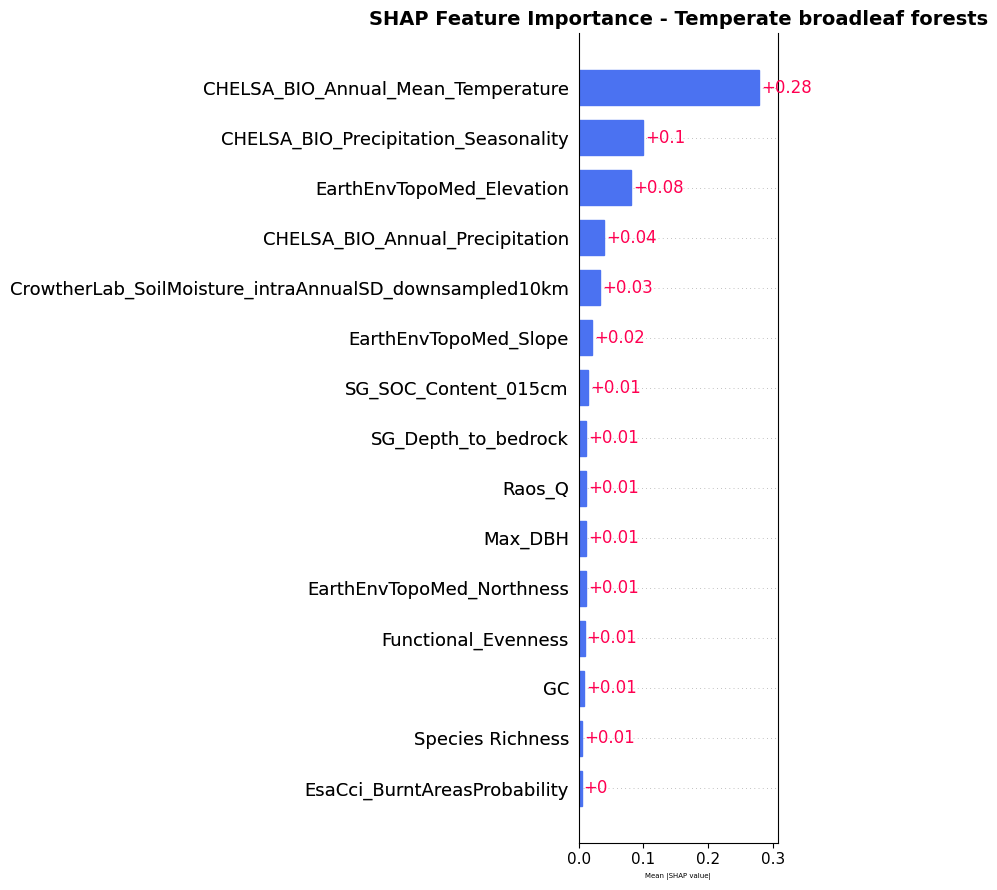